# Dans ce notebook nous allons commencer par chercher le jeu de données et le separer en entraînement/validation/test, nous allons aussi faire l'augmentation du jeu de donnée (avec des rotations principalement)
# Puis nous allons coder le U-Net.
Le code source est dans `glacier.model` :
- `dataset.py`
- `cnn_unet.py`
- `lost_functions.py`
- `training.py`

In [1]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

from glacier.data.data_fetching import repo_root
from glacier.model import (
    GlacierDataset,
    UNet,
    DiceBCELoss,
    compute_band_stats,
    discover_pairs,
    train_one_epoch,
    evaluate,
    plot_history,
    show_predictions,
)

ROOT = repo_root()

# Hyperparamètres
## J'ai mis ici en commentaire ce que nous utiliserons lorsqu'on fera un plus gros entrainement avec les HPC

In [2]:
SEED          = 42
BATCH_SIZE    = 4           # HPC avec GPU : 16 ou 32
EPOCHS        = 100         # HPC : 200+ si le dataset grandit
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PAD_TO        = 320         # multiple de 16 pour les 4 maxpools du U-Net
N_BANDS       = 5           # blue, green, red, nir, swir16
TRAIN_REGION  = "alps"
TEST_REGIONS  = ["caucasus", "andes"]
VAL_FRAC      = 0.20

COMPOSITES_ROOT = ROOT / "data" / "sentinel2" / "composites"
MASKS_ROOT      = ROOT / "data" / "sentinel2" / "glims_masks"
CHECKPOINT_DIR  = ROOT / "data" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# CPU local (par défaut)
DEVICE = torch.device("cpu")

# HPC : décommenter la ligne suivante pour utiliser le GPU
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


# Création du dataset en paire et split train/val/test

In [3]:
region_pairs = discover_pairs(COMPOSITES_ROOT, MASKS_ROOT)

  alps        : 30 paires
  andes       : 30 paires
  caucasus    : 30 paires


In [4]:
# Pour ce run test on a  Split train / val (Alpes) + test (Caucase, Andes) mais on va changer après parce que les Alpes sont celles avec le moins d'image.
alps_pairs = region_pairs.get(TRAIN_REGION, [])
n_val = max(1, int(len(alps_pairs) * VAL_FRAC))

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(alps_pairs))

train_pairs = [alps_pairs[i] for i in perm[n_val:]]
val_pairs   = [alps_pairs[i] for i in perm[:n_val]]
test_pairs  = {r: region_pairs.get(r, []) for r in TEST_REGIONS}

print(f"Train : {len(train_pairs)} (Alpes)")
print(f"Val   : {len(val_pairs)}  (Alpes)")
for r, p in test_pairs.items():
    print(f"Test  : {len(p):3d}  ({r})")

Train : 24 (Alpes)
Val   : 6  (Alpes)
Test  :  30  (caucasus)
Test  :  30  (andes)


In [5]:
# Stats de normalisation (train uniquement)
mean, std = compute_band_stats(train_pairs, n_bands=N_BANDS)
print("Mean par bande:", mean)
print("Std  par bande:", std)

Mean par bande: [0.22279756 0.2407384  0.24190757 0.24120837 0.0982881 ]
Std  par bande: [0.2748277  0.26376477 0.25438735 0.20662403 0.12191268]


In [6]:
train_ds = GlacierDataset(train_pairs, mean, std, augment=True,  pad_to=PAD_TO)
val_ds   = GlacierDataset(val_pairs,   mean, std, augment=False, pad_to=PAD_TO)
test_datasets = {
    r: GlacierDataset(p, mean, std, augment=False, pad_to=PAD_TO)
    for r, p in test_pairs.items()
}

# num_workers=0 sur Windows (en fait on avait une erreur quand on ne faisait aps ca a cause d'une incompatibilité avec rioxarray)
# pin_memory=True seulement avec GPU
# HPC : num_workers=4, pin_memory=True
NUM_WORKERS = 0
PIN_MEMORY  = False

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loaders = {
    r: DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    for r, ds in test_datasets.items()
}

## Apperçu 

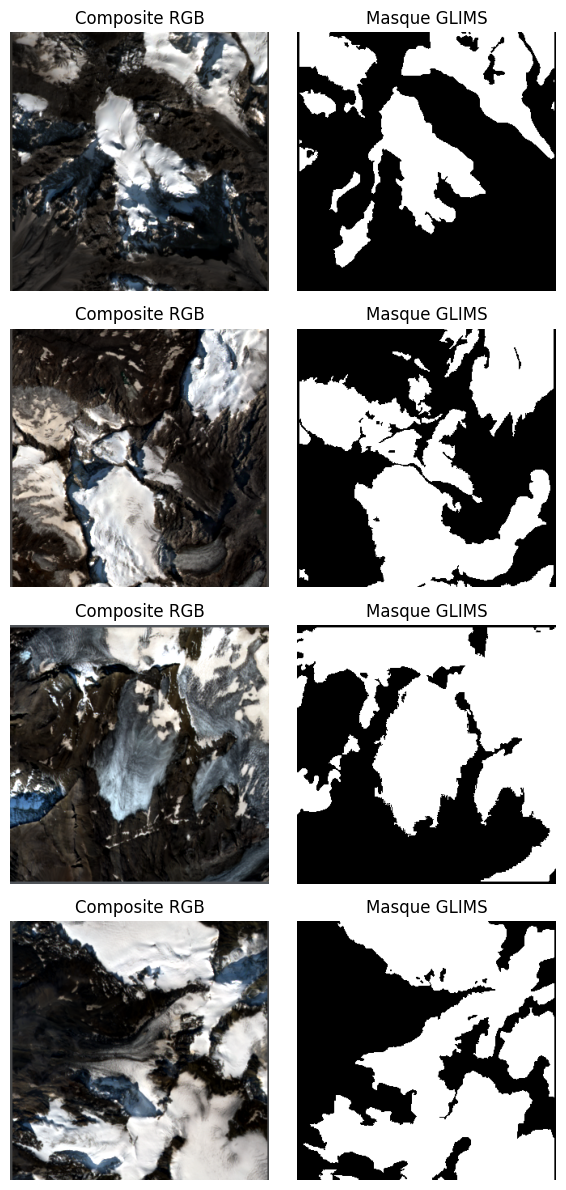

In [7]:
import matplotlib.pyplot as plt

def show_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes[np.newaxis]
    for i in range(min(n, len(dataset))):
        img, mask = dataset[i]
        rgb = img[[2, 1, 0]].numpy()
        for c in range(3):
            v = rgb[c][rgb[c] != 0]
            if len(v) > 0:
                lo, hi = np.percentile(v, [2, 98])
                rgb[c] = np.clip((rgb[c] - lo) / (hi - lo + 1e-6), 0, 1)
        axes[i, 0].imshow(rgb.transpose(1, 2, 0))
        axes[i, 0].set_title("Composite RGB")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(mask[0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Masque GLIMS")
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=4)

# Entrainement du modèle

In [8]:
model = UNet(in_channels=N_BANDS).to(DEVICE)

# Vérification des dimensions
dummy = torch.randn(1, N_BANDS, PAD_TO, PAD_TO, device=DEVICE)
out = model(dummy)
print(f"Entrée  : {tuple(dummy.shape)}")
print(f"Sortie  : {tuple(out.shape)}")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

Entrée  : (1, 5, 320, 320)
Sortie  : (1, 1, 320, 320)
Paramètres entraînables : 7,763,617


In [9]:
criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [], "lr": []}
best_val_iou = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_iou   = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)
    history["lr"].append(current_lr)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_iou": val_iou,
            "mean": mean,
            "std": std,
        }, CHECKPOINT_DIR / "best_unet.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"train loss {train_loss:.4f}  IoU {train_iou:.3f} | "
            f"val loss {val_loss:.4f}  IoU {val_iou:.3f} | "
            f"lr {current_lr:.2e}"
        )

print(f"\nMeilleur IoU validation : {best_val_iou:.4f}")

Epoch   1/100 | train loss 1.0492  IoU 0.547 | val loss 1.1598  IoU 0.642 | lr 1.00e-03
Epoch  10/100 | train loss 0.6127  IoU 0.695 | val loss 0.6334  IoU 0.682 | lr 9.80e-04
Epoch  20/100 | train loss 0.5211  IoU 0.728 | val loss 0.5178  IoU 0.694 | lr 9.14e-04
Epoch  30/100 | train loss 0.4674  IoU 0.742 | val loss 0.4883  IoU 0.701 | lr 8.07e-04
Epoch  40/100 | train loss 0.4471  IoU 0.747 | val loss 0.4882  IoU 0.694 | lr 6.70e-04
Epoch  50/100 | train loss 0.4346  IoU 0.758 | val loss 0.4704  IoU 0.714 | lr 5.16e-04
Epoch  60/100 | train loss 0.4133  IoU 0.765 | val loss 0.4641  IoU 0.719 | lr 3.61e-04
Epoch  70/100 | train loss 0.3957  IoU 0.769 | val loss 0.4747  IoU 0.707 | lr 2.20e-04
Epoch  80/100 | train loss 0.3711  IoU 0.780 | val loss 0.4782  IoU 0.718 | lr 1.06e-04
Epoch  90/100 | train loss 0.3678  IoU 0.782 | val loss 0.4730  IoU 0.714 | lr 3.05e-05
Epoch 100/100 | train loss 0.3619  IoU 0.786 | val loss 0.4741  IoU 0.717 | lr 1.25e-06

Meilleur IoU validation : 0.720

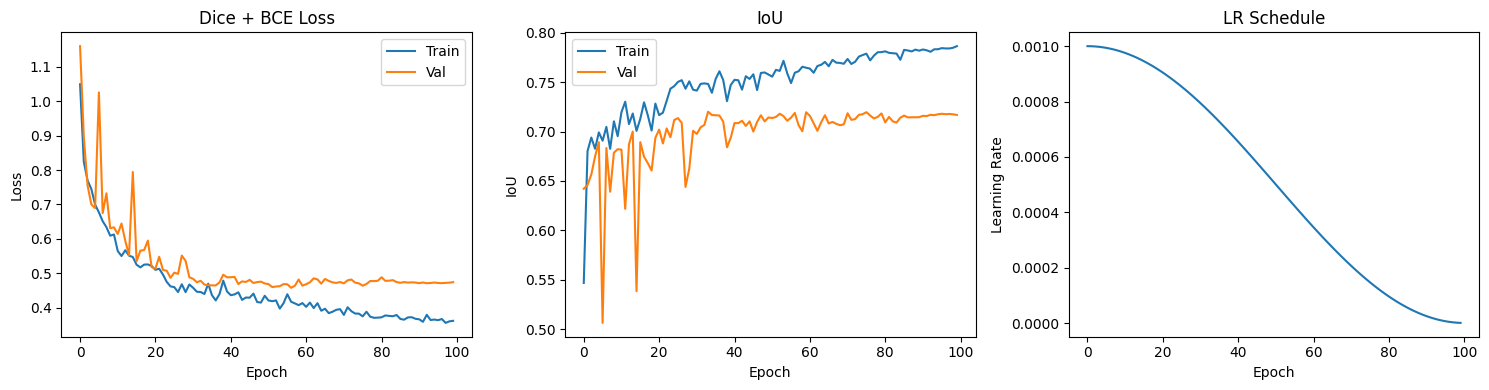

In [10]:
plot_history(history)

# Évaluation du modèle

In [11]:
ckpt = torch.load(CHECKPOINT_DIR / "best_unet.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Checkpoint chargé (epoch {ckpt['epoch']}, val IoU {ckpt['val_iou']:.4f})")

print("\n── Résultats ──")
val_loss, val_iou = evaluate(model, val_loader, criterion, DEVICE)
print(f"  {'alps (val)':15s} | loss {val_loss:.4f} | IoU {val_iou:.4f}")

for region, loader in test_loaders.items():
    if len(loader.dataset) == 0:
        print(f"  {region:15s} | aucune donnée")
        continue
    t_loss, t_iou = evaluate(model, loader, criterion, DEVICE)
    print(f"  {region:15s} | loss {t_loss:.4f} | IoU {t_iou:.4f}")

Checkpoint chargé (epoch 34, val IoU 0.7200)

── Résultats ──
  alps (val)      | loss 0.4672 | IoU 0.7200
  caucasus        | loss 0.4020 | IoU 0.7788
  andes           | loss 0.5209 | IoU 0.7632


── Prédictions validation (Alpes) ──


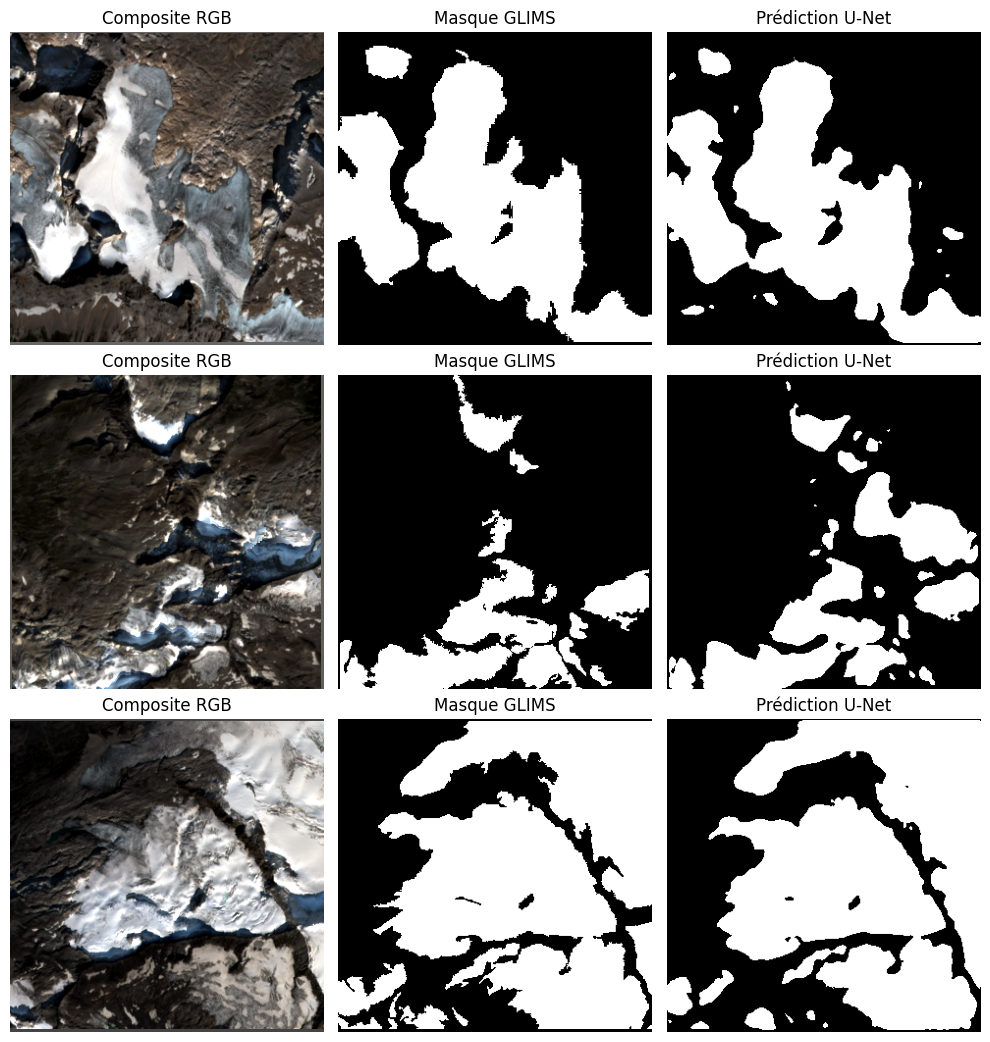


── Prédictions test (caucasus) ──


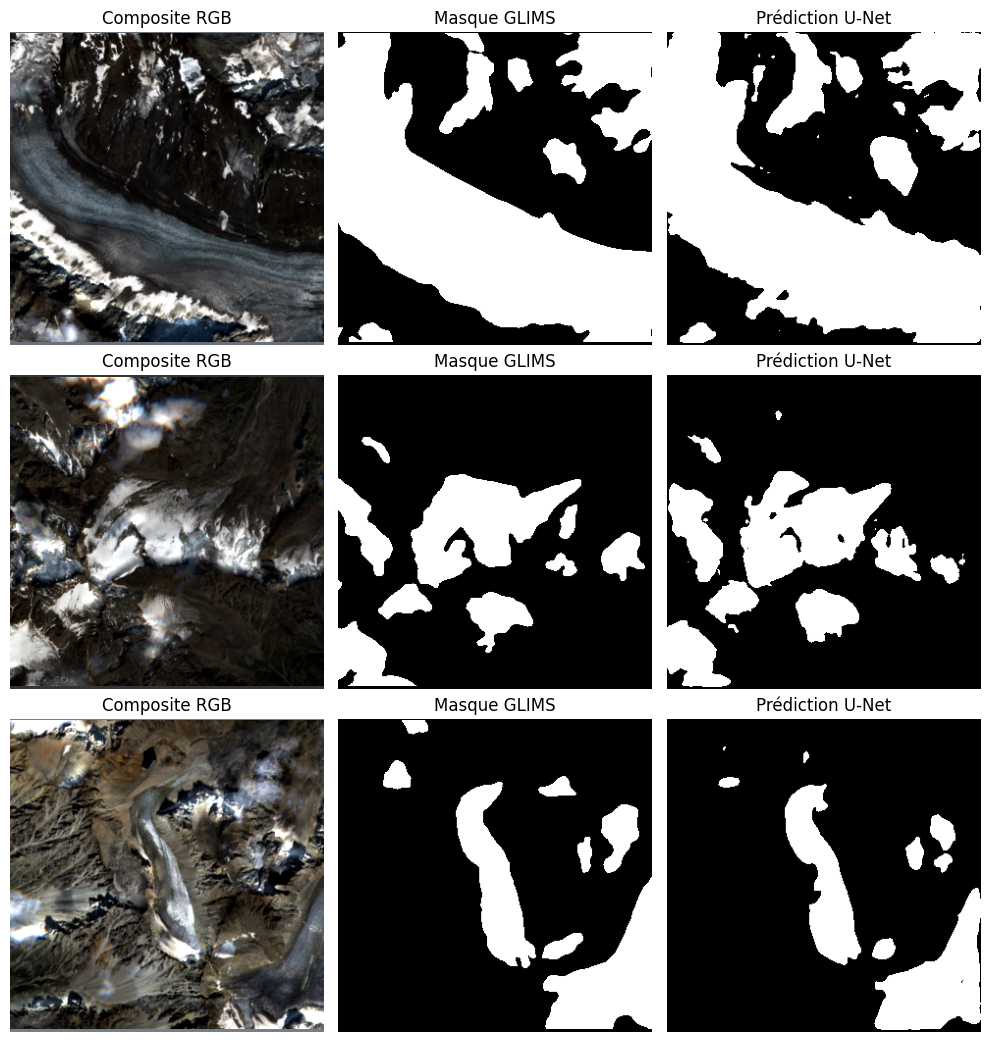


── Prédictions test (andes) ──


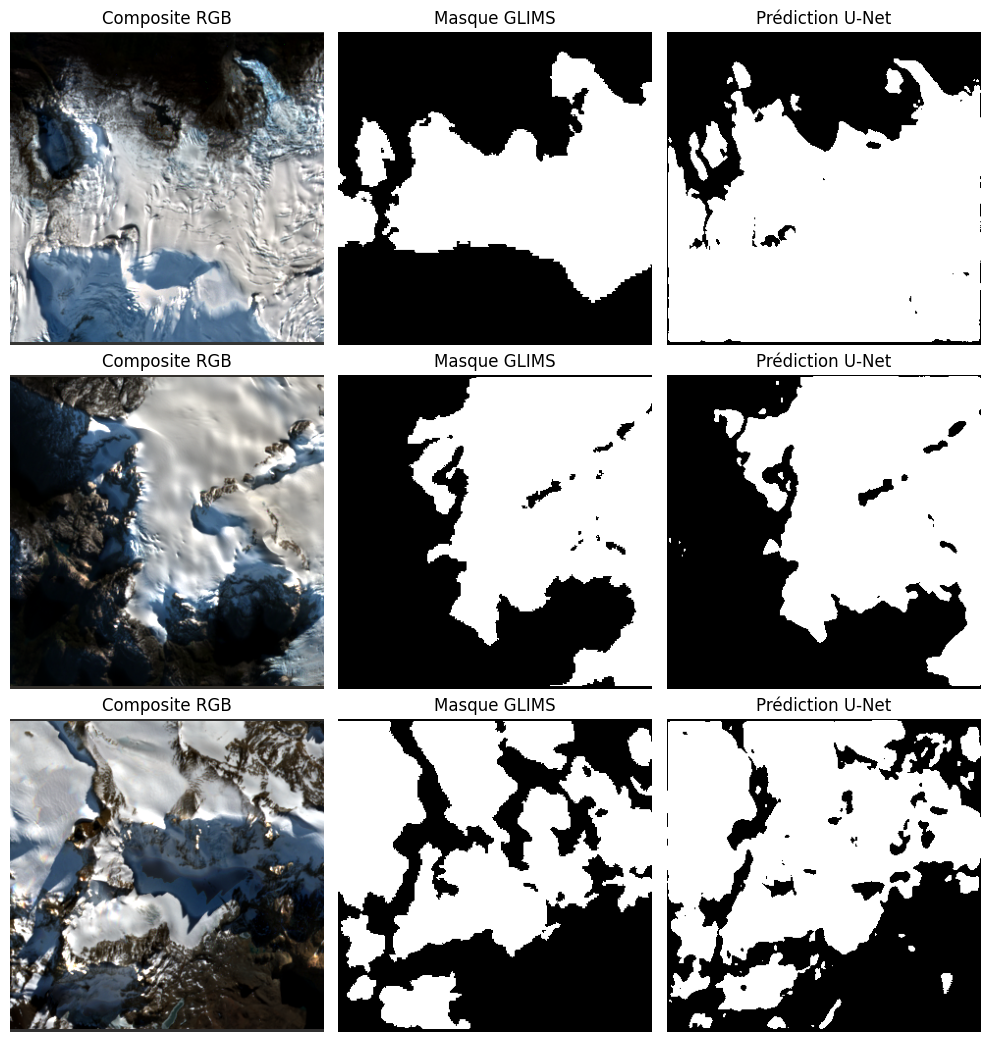

In [12]:
print("── Prédictions validation (Alpes) ──")
show_predictions(model, val_ds, DEVICE, n=3)

for region, ds in test_datasets.items():
    if len(ds) > 0:
        print(f"\n── Prédictions test ({region}) ──")
        show_predictions(model, ds, DEVICE, n=3)

## Sauvegarde du modèle comme ca on peut le récuperer après sans avoir a reentrainer

In [13]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "epoch": EPOCHS,
    "history": history,
    "best_val_iou": best_val_iou,
    "mean": mean,
    "std": std,
    "config": {
        "in_channels": N_BANDS,
        "features": [32, 64, 128, 256],
        "pad_to": PAD_TO,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    },
}, CHECKPOINT_DIR / "unet_final.pt")

print("Modèle sauvegardé dans", CHECKPOINT_DIR / "unet_final.pt")

Modèle sauvegardé dans C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\checkpoints\unet_final.pt
